In [ ]:
import glob
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import keras
import tensorflow as tf 
import tensorflow.keras as keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array, array_to_img
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, InputLayer, Rescaling
from keras.models import Sequential, Model, load_model
from keras import optimizers
from keras.applications import vgg16
import os
import random
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import imghdr

#### Remove weird stuff

In [9]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [ ]:

#Define paths
root_dir = "C:/Users/User/Desktop/Python bs/Prophet/Tostas/Images"
output_dir = "C:/Users/User/Desktop/Python bs/Prophet/Tostas/trainTestValSet" 

#Define split ratios
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

#Create output directories with category subfolders
for split in ['train', 'val', 'test']:
    for category in os.listdir(root_dir):
        category_path = os.path.join(root_dir, category)
        if os.path.isdir(category_path):  # Ensure it's a folder
            os.makedirs(os.path.join(output_dir, split, category), exist_ok=True)

#Process each category
for category in os.listdir(root_dir):
    category_path = os.path.join(root_dir, category)
    if not os.path.isdir(category_path):
        continue
    
    #Get all image paths in the category folder
    images = [os.path.join(category_path, img) for img in os.listdir(category_path) if img.endswith(('jpg', 'png', 'jpeg'))]
    
    #Shuffle and split images
    train_imgs, temp_imgs = train_test_split(images, test_size=(val_ratio + test_ratio), random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=test_ratio / (val_ratio + test_ratio), random_state=42)
    
    #Copy images to respective directories
    for img in train_imgs:
        shutil.copy(img, os.path.join(output_dir, 'train', category, os.path.basename(img)))
    for img in val_imgs:
        shutil.copy(img, os.path.join(output_dir, 'val', category, os.path.basename(img)))
    for img in test_imgs:
        shutil.copy(img, os.path.join(output_dir, 'test', category, os.path.basename(img)))


#### Data load stuff

In [ ]:
input_shape = (224, 224, 3) 
num_classes = 2 
batch_size = 32
epochs = 5

#Load MobileNet base model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=input_shape)

#Freeze model
base_model.trainable = False

#Simple model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='sigmoid')  #Softmax for multi-class classification, sigmoid for binary
])

#Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  #Use categorical_crossentropy for multi-class classification, binary for well... yes or now classifications xD
    metrics=['accuracy']
)

#model summary
model.summary()

#Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  #Use a subset of training data for validation, split of 80/20
)

train_generator = train_datagen.flow_from_directory(
    "C:/Users/User/Desktop/Python bs/Prophet/Tostas/trainTestValSet/train",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "C:/Users/User/Desktop/Python bs/Prophet/Tostas/trainTestValSet/val",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

#Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_steps=val_generator.samples // batch_size
)

#Save the model
model.save("mobilenet_model.h5")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,754,690 (14.32 MB)

 Trainable params: 525,826 (2.01 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

Found 6720 images belonging to 2 classes.
Found 480 images belonging to 2 classes.
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 187s 876ms/step - accuracy: 0.7247 - loss: 0.5511 - val_accuracy: 0.8354 - val_loss: 0.3825
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/5


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2032.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


210/210 ━━━━━━━━━━━━━━━━━━━━ 130s 619ms/step - accuracy: 0.8296 - loss: 0.3791 - val_accuracy: 0.8458 - val_loss: 0.3437
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 121us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 132s 628ms/step - accuracy: 0.8500 - loss: 0.3300 - val_accuracy: 0.8521 - val_loss: 0.3315


In [ ]:
#Not bad, 85% accuracy with an equal val accuracy, that means it isnt overfitting, the same can be observed with the loss functions.

Found 1202 images belonging to 2 classes.
38/38 ━━━━━━━━━━━━━━━━━━━━ 24s 611ms/step


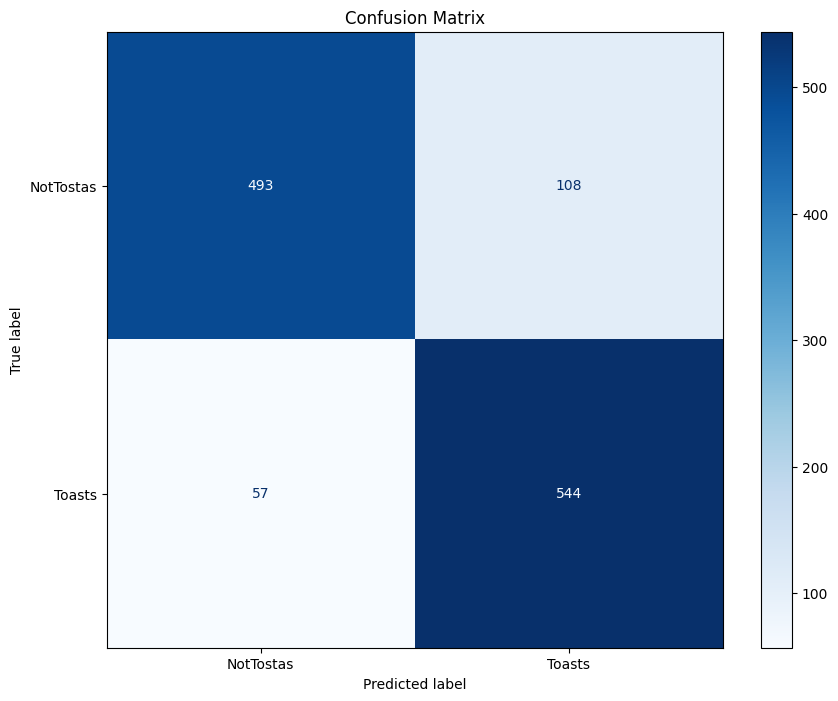

In [ ]:
#Load the test dataset
test_datagen = ImageDataGenerator(rescale=1.0 / 255)  #No augmentation for the test set
test_generator = test_datagen.flow_from_directory(
    "C:/Users/User/Desktop/Python bs/Prophet/Tostas/trainTestValSet/test",
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

#Predict on the test dataset
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())  #Class labels

#Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

#Plot confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title("Confusion Matrix")
plt.show()


Prediction tests

In [24]:
from tensorflow.keras.models import load_model
model = load_model('mobilenet_model.h5')

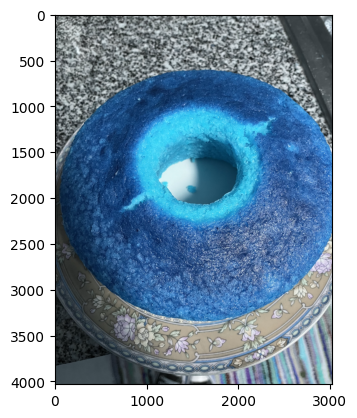

In [25]:
img = cv2.imread('TostaMargarida.jpg')
plt.imshow(img)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


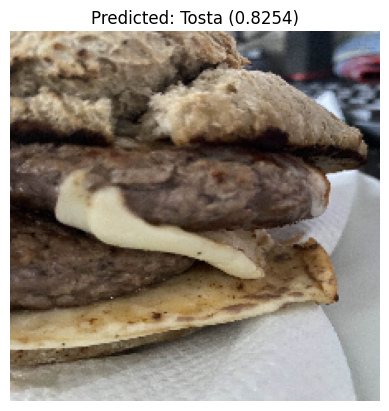

Scores for all classes: [0.15198117 0.8254408 ]
Predicted Class: Tosta with score 0.8254


In [ ]:
#Define the class labels manually (based on the order of directories during training)
class_labels = ['Not Tosta', 'Tosta']

def test_model_with_image(model, image_path, class_labels):
    #Load and preprocess the image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale image to [0, 1], a normalization

    #Predict the image class
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)  #Index of the class with highest score

    #Get the predicted class label
    predicted_label = class_labels[predicted_class_index[0]]
    predicted_score = predictions[0][predicted_class_index[0]]

    #Show the image and the predicted label with score
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_label} ({predicted_score:.4f})")
    plt.axis("off")
    plt.show()

    #Print the scores for all classes
    print("Scores for all classes:", predictions[0])
    print(f"Predicted Class: {predicted_label} with score {predicted_score:.4f}")

#Example of usage
#test_model_with_image(model, 'TostaMargarida.jpg', class_labels)
#test_model_with_image(model, 'TostaJoao.png', class_labels)
#test_model_with_image(model, 'toastgoncalo.jpg', class_labels)
#test_model_with_image(model, 'sushi goncalo.jpg', class_labels)
test_model_with_image(model, 'IMG_1822.jpg', class_labels)

